# Mini-TP (20 min) — Filtres de Gabor sur l’image de Lena

**Public :** M1 Ingénierie • **Objectif :** visualiser l’effet des filtres de Gabor (orientation & fréquence spatiale) pour détecter des textures et motifs orientés.


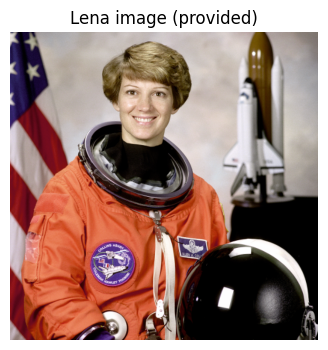

In [1]:
# === Setup: imports & image ===
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

img_path = 'lena_demo.png'
if not os.path.exists(img_path):
    raise FileNotFoundError("Place 'lena_demo.png' in the working directory.")
img_rgb = np.array(Image.open(img_path))
img_gray = np.dot(img_rgb[...,:3], [0.299, 0.587, 0.114]) / 255.0

plt.figure(figsize=(5,4))
plt.imshow(img_rgb)
plt.title("Lena image (provided)")
plt.axis('off')
plt.show()


In [2]:
# === Generate Gabor kernel ===
def gabor_kernel(ksize=31, sigma=6.0, theta=np.pi/4, lam=10.0, gamma=0.5, phi=0.0):
    import numpy as np
    assert ksize % 2 == 1
    half = ksize // 2
    y, x = np.meshgrid(np.arange(-half, half+1), np.arange(-half, half+1), indexing='xy')
    x_p =  x*np.cos(theta) + y*np.sin(theta)
    y_p = -x*np.sin(theta) + y*np.cos(theta)
    gauss = np.exp(-(x_p**2 + (gamma**2)*(y_p**2)) / (2*sigma**2))
    sinus = np.cos(2*np.pi * x_p/lam + phi)
    g = gauss * sinus
    g -= g.mean()
    s = np.sqrt((g**2).sum())
    if s > 1e-8:
        g /= s
    return g


In [3]:
# === Simple 2D convolution ===
def conv2_valid(img, kernel):
    H, W = img.shape
    k = kernel.shape[0]
    out_h = H - k + 1
    out_w = W - k + 1
    out = np.zeros((out_h, out_w), dtype=np.float32)
    kr = kernel[::-1, ::-1]
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(img[i:i+k, j:j+k] * kr)
    return out

def conv2_same(img, kernel):
    k = kernel.shape[0]
    pad = k//2
    img_p = np.pad(img, ((pad,pad),(pad,pad)), mode='reflect')
    return conv2_valid(img_p, kernel)


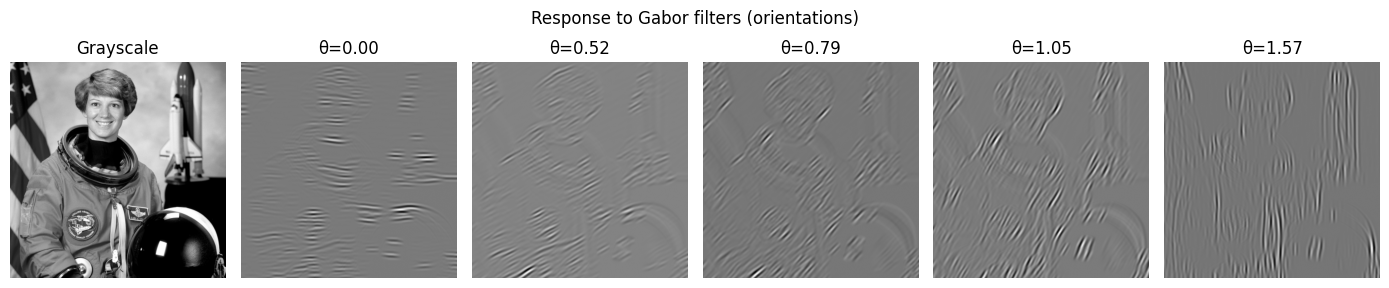

In [4]:
# === Orientation demo ===
thetas = [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2]
k = 31
lam = 10.0
gamma = 0.5
sigma = 6.0

fig, axes = plt.subplots(1, len(thetas)+1, figsize=(14,3))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Grayscale"); axes[0].axis('off')

for idx, th in enumerate(thetas, start=1):
    g = gabor_kernel(ksize=k, sigma=sigma, theta=th, lam=lam, gamma=gamma, phi=0.0)
    resp = conv2_same(img_gray, g)
    axes[idx].imshow(resp, cmap='gray')
    axes[idx].set_title(f"θ={th:.2f}")
    axes[idx].axis('off')

plt.suptitle("Response to Gabor filters (orientations)")
plt.tight_layout()
plt.show()


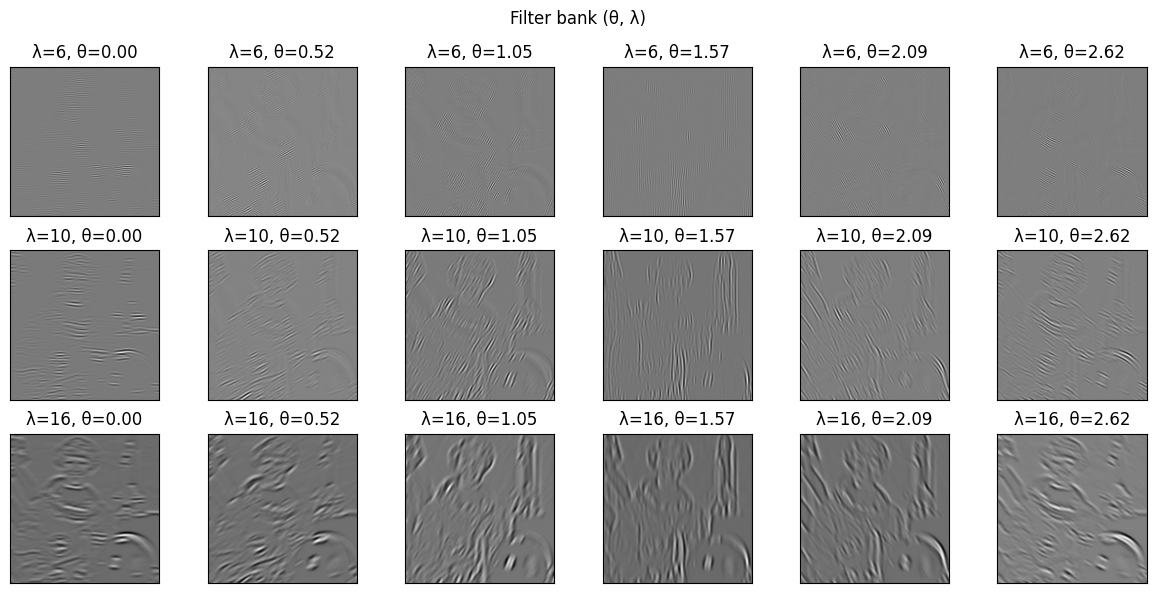

In [5]:
# === Explore θ and λ ===
thetas = np.linspace(0, np.pi, 6, endpoint=False)
lambdas = [6.0, 10.0, 16.0]

fig, axes = plt.subplots(len(lambdas), len(thetas), figsize=(12,6))
for i, lam in enumerate(lambdas):
    for j, th in enumerate(thetas):
        g = gabor_kernel(ksize=31, sigma=6.0, theta=th, lam=lam, gamma=0.5, phi=0.0)
        resp = conv2_same(img_gray, g)
        axes[i, j].imshow(resp, cmap='gray')
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, j].set_title(f"λ={lam:.0f}, θ={th:.2f}")
plt.suptitle("Filter bank (θ, λ)")
plt.tight_layout()
plt.show()


## Questions rapides (5 min)
1. Comment évolue la réponse lorsque θ varie ? Identifier les textures orientées (cheveux, tissus, contours...).  
2. Quel est l’effet de λ (fréquence spatiale) ? Quelles structures sont mieux détectées avec des valeurs petites vs grandes ?  
3. Pourquoi normaliser le noyau (moyenne nulle, norme unité) avant convolution ?  
4. Bonus : comment construire une carte d’orientation en agrégeant les réponses ? (indice : max sur θ, gestion de phase).


Reponses

1. Lorsque thêta varie : on obtient les contours qui s'alignent avec l'angle thêta (0=horizontale).
Les cheveux sont horizontaux, la fusée est principalement verticale, le drapeau en biais (thêta=2.09), les contours de Lena sont bien visibles à la verticale,...

2. lambda est la période spatiale (1/freq), plus lambda est petit (haute freq spatiale) plus le filtre détecte les motifs fins, les textures sérrées, les contours précis. Inversement il détecte mieux les structures larges, floues, aux contours répartis
Les bandes du drapeau, les contours de Lena, de la fusée, du casque se voient mieux avec lambda = 16
En revanche, les chaveux, les yeux, les lèvres, le bas du nez peuvent se voir à l'horizontale pour lambda = 10

3. On normalise le noyau pour que le résultat soit comparable à d'autres de filtres différents (supperpositions). Cela consiste à mettre la moyenne à 0 pour éliminer le biais en DC, afin d'avoir 0 luminance dans les sur zones uniformes. Puis on fait la norme unité pour uniformiser la puissance de chaque filtre, sinon un filtre risque d'être déséquilibré par rapport aux autres (l'intensité dépendra du filtre plutôt que de l'image).


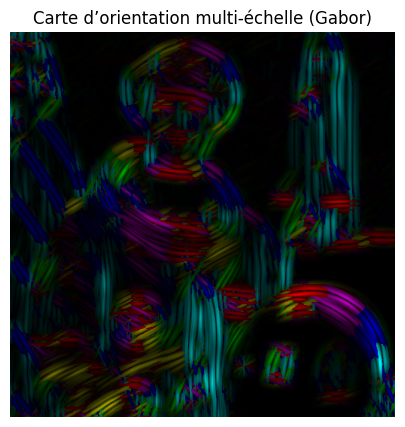

In [6]:
#Carte d’orientation (multi-fréquences)
thetas = np.linspace(0, np.pi, 6, endpoint=False) # 6 orientations
lambdas = [6.0, 10.0, 16.0] # 3 fréquences spatiales

responses = []

# Calcul des réponses pour toutes les (thêta, lambda)
for lam in lambdas:
    for th in thetas:
        g = gabor_kernel(ksize=31, sigma=6.0, theta=th, lam=lam, gamma=0.5)
        r = np.abs(conv2_same(img_gray, g))
        responses.append(r)

responses = np.stack(responses, axis=0) # shape = (N_lambda×N_thêta, H, W)

#  Regrouper par orientation : somme des fréquences
responses = responses.reshape(len(lambdas), len(thetas), *img_gray.shape)
A_theta = responses.sum(axis=0) # somme sur les lambda

# Orientation dominante
amplitude = A_theta.max(axis=0)
orientation_idx = A_theta.argmax(axis=0)
orientation_map = thetas[orientation_idx]

# Affichage coloré
import matplotlib.colors as mcolors
hsv = np.zeros((*orientation_map.shape, 3))
hsv[..., 0] = orientation_map / np.pi
hsv[..., 1] = 1.0
hsv[..., 2] = amplitude / amplitude.max()
orientation_rgb = mcolors.hsv_to_rgb(hsv)

plt.figure(figsize=(6,5))
plt.imshow(orientation_rgb)
plt.title("Carte d’orientation multi-échelle (Gabor)")
plt.axis('off')
plt.show()


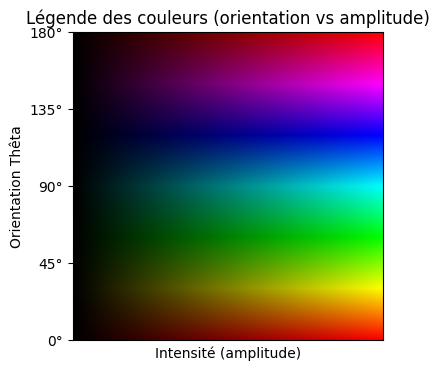

In [7]:
#Légende
N = 200
r = np.linspace(0, 1, N)
theta = np.linspace(0, np.pi, N)  # 0 à 180°
R, T = np.meshgrid(r, theta)

# Conversion angle -> teinte (0..1)
H = T / np.pi
S = np.ones_like(H)
V = R
hsv = np.stack((H, S, V), axis=-1)
rgb = mcolors.hsv_to_rgb(hsv)

plt.figure(figsize=(4, 4))
plt.imshow(rgb, extent=[0, 1, 0, np.pi], aspect='auto', origin='lower')
plt.yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
           ["0°", "45°", "90°", "135°", "180°"])
plt.xticks([])
plt.xlabel("Intensité (amplitude)")
plt.ylabel("Orientation Thêta")
plt.title("Légende des couleurs (orientation vs amplitude)")
plt.show()
